# Model B Training — Surprise-Only Propagation vs Baseline

This notebook trains Model B (surprise-only propagation) and Baseline (standard convolutions) on SkinSense data.

**Key metric:** Gate activation over time. If gates drop from 0.5 → 0.2, surprise propagation works.

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import pandas as pd
import numpy as np
from PIL import Image
import os
import json
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4060


## 2. Data Loading

In [2]:
class SkinDataset(Dataset):
    """Load images from CSV with image_path and numeric_label columns."""
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['image_path']
        label = row['numeric_label']
        
        try:
            image = Image.open(image_path).convert('RGB')
        except Exception as e:
            # Fallback to blank image if load fails
            image = Image.new('RGB', (224, 224))
            
        if self.transform:
            image = self.transform(image)
            
        return image, label

print("SkinDataset defined")

SkinDataset defined


In [3]:
def get_dataloaders(data_dir, batch_size=32, num_workers=4):
    """Create train/val/test dataloaders matching your setup."""
    
    IMG_SIZE = 224
    
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                            std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                            std=[0.229, 0.224, 0.225])
    ])
    
    train_dataset = SkinDataset(f'{data_dir}/train.csv', transform=train_transform)
    val_dataset = SkinDataset(f'{data_dir}/val.csv', transform=val_transform)
    test_dataset = SkinDataset(f'{data_dir}/test.csv', transform=val_transform)
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, val_loader, test_loader

print("DataLoader function defined")

DataLoader function defined


## 3. Model Architecture

In [4]:
class PredictiveLayer(nn.Module):
    """Encodes, predicts, and gates surprise signal."""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
        self.predictor = nn.Sequential(
            nn.Conv2d(out_channels, in_channels, 1, bias=False),
            nn.BatchNorm2d(in_channels)
        )
        
        self.error_encoder = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
        self.surprise_gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(out_channels, out_channels),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        prediction = self.predictor(encoded)
        
        if prediction.shape != x.shape:
            prediction = F.interpolate(prediction, size=x.shape[2:], mode='bilinear', align_corners=False)
        
        error = x - prediction
        error_encoded = self.error_encoder(error)
        
        gate = self.surprise_gate(error_encoded)
        gate = gate.unsqueeze(-1).unsqueeze(-1)
        gated_error = error_encoded * gate
        
        return gated_error, prediction, error, gate.squeeze(-1).squeeze(-1)

print("PredictiveLayer defined")

PredictiveLayer defined


In [5]:
class ModelB(nn.Module):
    """Full Model B: surprise-only propagation."""
    def __init__(self, num_classes=7):
        super().__init__()
        
        self.layer1 = PredictiveLayer(3, 32, stride=1)
        self.layer2 = PredictiveLayer(32, 64, stride=2)
        self.layer3 = PredictiveLayer(64, 128, stride=2)
        self.layer4 = PredictiveLayer(128, 256, stride=2)
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        error1, pred1, raw_err1, gate1 = self.layer1(x)
        error2, pred2, raw_err2, gate2 = self.layer2(error1)
        error3, pred3, raw_err3, gate3 = self.layer3(error2)
        error4, pred4, raw_err4, gate4 = self.layer4(error3)
        
        pooled = self.global_pool(error4)
        logits = self.fc(pooled.view(pooled.size(0), -1))
        
        aux = {
            'predictions': [pred1, pred2, pred3, pred4],
            'errors': [raw_err1, raw_err2, raw_err3, raw_err4],
            'gates': [gate1, gate2, gate3, gate4],
            'inputs': [x, error1, error2, error3]
        }
        
        return logits, aux

print("ModelB defined")

ModelB defined


In [5]:
class StandardConvLayer(nn.Module):
    """Standard conv block for baseline."""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)


class Baseline(nn.Module):
    """Baseline: standard convolutions, full activations."""
    def __init__(self, num_classes=7):
        super().__init__()
        
        self.layer1 = StandardConvLayer(3, 32, stride=1)
        self.layer2 = StandardConvLayer(32, 64, stride=2)
        self.layer3 = StandardConvLayer(64, 128, stride=2)
        self.layer4 = StandardConvLayer(128, 256, stride=2)
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, 7)
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        pooled = self.global_pool(x)
        logits = self.fc(pooled.view(pooled.size(0), -1))
        
        return logits, {}

print("Baseline defined")

Baseline defined


In [4]:
class PredictiveLayerBetterPredictor(nn.Module):
    """FIX B: Improved predictor with more capacity."""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
        # Better predictor: 2 layers instead of 1
        self.predictor = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, in_channels, 1, bias=False),
            nn.BatchNorm2d(in_channels)
        )
        
        self.error_encoder = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
        self.surprise_gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(out_channels, out_channels),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        prediction = self.predictor(encoded)
        
        if prediction.shape != x.shape:
            prediction = F.interpolate(prediction, size=x.shape[2:], mode='bilinear', align_corners=False)
        
        error = x - prediction
        error_encoded = self.error_encoder(error)
        
        gate = self.surprise_gate(error_encoded)
        gate = gate.unsqueeze(-1).unsqueeze(-1)
        gated_error = error_encoded * gate
        
        return gated_error, prediction, error, gate.squeeze(-1).squeeze(-1)


class ModelBv2_NoReconstruction(nn.Module):
    """FIX A: Remove reconstruction loss (classify-only)."""
    def __init__(self, num_classes=7):
        super().__init__()
        
        self.layer1 = PredictiveLayer(3, 32, stride=1)
        self.layer2 = PredictiveLayer(32, 64, stride=2)
        self.layer3 = PredictiveLayer(64, 128, stride=2)
        self.layer4 = PredictiveLayer(128, 256, stride=2)
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        error1, pred1, raw_err1, gate1 = self.layer1(x)
        error2, pred2, raw_err2, gate2 = self.layer2(error1)
        error3, pred3, raw_err3, gate3 = self.layer3(error2)
        error4, pred4, raw_err4, gate4 = self.layer4(error3)
        
        pooled = self.global_pool(error4)
        logits = self.fc(pooled.view(pooled.size(0), -1))
        
        aux = {
            'gates': [gate1, gate2, gate3, gate4]
        }
        
        return logits, aux


class ModelBv2b_BetterPredictor(nn.Module):
    """FIX B: Improved predictor capacity."""
    def __init__(self, num_classes=7):
        super().__init__()
        
        self.layer1 = PredictiveLayerBetterPredictor(3, 32, stride=1)
        self.layer2 = PredictiveLayerBetterPredictor(32, 64, stride=2)
        self.layer3 = PredictiveLayerBetterPredictor(64, 128, stride=2)
        self.layer4 = PredictiveLayerBetterPredictor(128, 256, stride=2)
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        error1, pred1, raw_err1, gate1 = self.layer1(x)
        error2, pred2, raw_err2, gate2 = self.layer2(error1)
        error3, pred3, raw_err3, gate3 = self.layer3(error2)
        error4, pred4, raw_err4, gate4 = self.layer4(error3)
        
        pooled = self.global_pool(error4)
        logits = self.fc(pooled.view(pooled.size(0), -1))
        
        aux = {
            'gates': [gate1, gate2, gate3, gate4]
        }
        
        return logits, aux

print("FIX A and FIX B models defined")

FIX A and FIX B models defined


## 4. Loss Functions

In [7]:
def model_b_loss(logits, targets, aux, 
                 w_class=1.0, w_recon=0.1, w_sparse=0.01):
    """Multi-component loss for Model B."""
    
    class_loss = F.cross_entropy(logits, targets)
    
    # Reconstruction loss
    recon_loss = 0
    for pred, target_input in zip(aux['predictions'], aux['inputs']):
        if pred.shape != target_input.shape:
            pred = F.interpolate(pred, size=target_input.shape[2:], mode='bilinear', align_corners=False)
        recon_loss += F.mse_loss(pred, target_input)
    recon_loss /= len(aux['predictions'])
    
    # Sparsity loss
    sparse_loss = 0
    for gate in aux['gates']:
        sparse_loss += gate.mean()
    sparse_loss /= len(aux['gates'])
    
    total_loss = (w_class * class_loss + 
                  w_recon * recon_loss + 
                  w_sparse * sparse_loss)
    
    return {
        'total': total_loss,
        'classification': class_loss.item(),
        'reconstruction': recon_loss.item(),
        'sparsity': sparse_loss.item()
    }


def baseline_loss(logits, targets):
    """Simple cross-entropy for baseline."""
    ce = F.cross_entropy(logits, targets)
    return {'total': ce, 'classification': ce.item()}

print("Loss functions defined")

Loss functions defined


In [6]:
def model_b_loss_no_reconstruction(logits, targets, aux, w_class=1.0, w_sparse=0.01):
    """FIX A: Classification + Sparsity only (no reconstruction)."""
    class_loss = F.cross_entropy(logits, targets)
    sparse_loss = sum(gate.mean() for gate in aux['gates']) / len(aux['gates'])
    
    total_loss = w_class * class_loss + w_sparse * sparse_loss
    
    return {
        'total': total_loss,
        'classification': class_loss.item(),
        'sparsity': sparse_loss.item()
    }


def model_b_loss_higher_sparsity(logits, targets, aux, w_class=1.0, w_sparse=0.05):
    """FIX B: Classification + Higher sparsity weight (0.05 instead of 0.01)."""
    class_loss = F.cross_entropy(logits, targets)
    sparse_loss = sum(gate.mean() for gate in aux['gates']) / len(aux['gates'])
    
    total_loss = w_class * class_loss + w_sparse * sparse_loss
    
    return {
        'total': total_loss,
        'classification': class_loss.item(),
        'sparsity': sparse_loss.item()
    }

print("FIX A and FIX B loss functions defined")

FIX A and FIX B loss functions defined


## 5. Training & Evaluation

In [8]:
def train_epoch(model, train_loader, optimizer, model_type='b'):
    """Train one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    gate_activations = []
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        if model_type == 'b':
            logits, aux = model(images)
            loss_dict = model_b_loss(logits, labels, aux)
            loss = loss_dict['total']
            gate_activations.extend([g.mean().item() for g in aux['gates']])
        else:
            logits, _ = model(images)
            loss_dict = baseline_loss(logits, labels)
            loss = loss_dict['total']
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss_dict['total'].item() if isinstance(loss_dict['total'], torch.Tensor) else loss_dict['total']
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    avg_loss = total_loss / len(train_loader)
    avg_acc = correct / total
    avg_gate = np.mean(gate_activations) if gate_activations else 0
    
    return avg_loss, avg_acc, avg_gate


def eval_epoch(model, eval_loader, model_type='b'):
    """Evaluate one epoch."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    gate_activations = []
    
    with torch.no_grad():
        for images, labels in eval_loader:
            images, labels = images.to(device), labels.to(device)
            
            if model_type == 'b':
                logits, aux = model(images)
                loss_dict = model_b_loss(logits, labels, aux)
                gate_activations.extend([g.mean().item() for g in aux['gates']])
            else:
                logits, _ = model(images)
                loss_dict = baseline_loss(logits, labels)
            
            total_loss += loss_dict['total'].item() if isinstance(loss_dict['total'], torch.Tensor) else loss_dict['total']
            _, predicted = logits.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / len(eval_loader)
    avg_acc = correct / total
    avg_gate = np.mean(gate_activations) if gate_activations else 0
    
    return avg_loss, avg_acc, avg_gate

print("Train/eval functions defined")

Train/eval functions defined


In [9]:
def train_model(model, train_loader, val_loader, test_loader, epochs, 
                model_type='b', output_dir='./checkpoints', lr=1e-3):
    """Main training loop."""
    
    os.makedirs(output_dir, exist_ok=True)
    model = model.to(device)
    
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    history = {
        'train_loss': [], 'train_acc': [], 'train_gate': [],
        'val_loss': [], 'val_acc': [], 'val_gate': [],
        'test_loss': [], 'test_acc': [], 'test_gate': []
    }
    
    best_val_acc = 0
    best_epoch = 0
    
    print(f"\n{'='*80}")
    print(f"Training {model_type.upper()} for {epochs} epochs")
    print(f"{'='*80}\n")
    
    for epoch in range(epochs):
        # Train
        train_loss, train_acc, train_gate = train_epoch(model, train_loader, optimizer, model_type)
        
        # Validate
        val_loss, val_acc, val_gate = eval_epoch(model, val_loader, model_type)
        
        # Test
        test_loss, test_acc, test_gate = eval_epoch(model, test_loader, model_type)
        
        scheduler.step()
        
        # Record
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_gate'].append(train_gate)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_gate'].append(val_gate)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['test_gate'].append(test_gate)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), f'{output_dir}/best_model.pth')
        
        # Log
        if (epoch + 1) % 5 == 0 or epoch == 0:
            gate_str = f"  gate_train: {train_gate:.4f}  gate_val: {val_gate:.4f}" if model_type == 'b' else ""
            print(f"Epoch {epoch+1:3d}/{epochs}  |  "
                  f"Train: {train_acc:.4f} acc  {train_loss:.4f} loss  |  "
                  f"Val: {val_acc:.4f} acc  {val_loss:.4f} loss  |  "
                  f"Test: {test_acc:.4f} acc{gate_str}")
    
    print(f"\nBest validation accuracy: {best_val_acc:.4f} at epoch {best_epoch+1}")
    
    # Save history
    with open(f'{output_dir}/history.json', 'w') as f:
        json.dump(history, f, indent=2)
    
    return model, history

print("Training function defined")

Training function defined


In [10]:
def train_epoch(model, train_loader, optimizer, loss_fn, model_type='b'):
    """Train one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    gate_activations = []
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        logits, aux = model(images)
        loss_dict = loss_fn(logits, labels, aux)  # Use passed loss_fn
        loss = loss_dict['total']
        gate_activations.extend([g.mean().item() for g in aux['gates']])
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss_dict['total'].item() if isinstance(loss_dict['total'], torch.Tensor) else loss_dict['total']
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    avg_loss = total_loss / len(train_loader)
    avg_acc = correct / total
    avg_gate = np.mean(gate_activations) if gate_activations else 0
    
    return avg_loss, avg_acc, avg_gate


def eval_epoch(model, eval_loader, loss_fn, model_type='b'):
    """Evaluate one epoch."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    gate_activations = []
    
    with torch.no_grad():
        for images, labels in eval_loader:
            images, labels = images.to(device), labels.to(device)
            
            logits, aux = model(images)
            loss_dict = loss_fn(logits, labels, aux)  # Use passed loss_fn
            
            total_loss += loss_dict['total'].item() if isinstance(loss_dict['total'], torch.Tensor) else loss_dict['total']
            _, predicted = logits.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            gate_activations.extend([g.mean().item() for g in aux['gates']])
    
    avg_loss = total_loss / len(eval_loader)
    avg_acc = correct / total
    avg_gate = np.mean(gate_activations) if gate_activations else 0
    
    return avg_loss, avg_acc, avg_gate


def train_model(model, train_loader, val_loader, test_loader, loss_fn, epochs, model_type='b', output_dir='./checkpoints', lr=1e-3):
    """Main training loop."""
    
    os.makedirs(output_dir, exist_ok=True)
    model = model.to(device)
    
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    history = {
        'train_loss': [], 'train_acc': [], 'train_gate': [],
        'val_loss': [], 'val_acc': [], 'val_gate': [],
        'test_loss': [], 'test_acc': [], 'test_gate': []
    }
    
    best_val_acc = 0
    best_epoch = 0
    
    print(f"\n{'='*80}")
    print(f"Training for {epochs} epochs")
    print(f"{'='*80}\n")
    
    for epoch in range(epochs):
        # Train
        train_loss, train_acc, train_gate = train_epoch(model, train_loader, optimizer, loss_fn, model_type)
        
        # Validate
        val_loss, val_acc, val_gate = eval_epoch(model, val_loader, loss_fn, model_type)
        
        # Test
        test_loss, test_acc, test_gate = eval_epoch(model, test_loader, loss_fn, model_type)
        
        scheduler.step()
        
        # Record
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_gate'].append(train_gate)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_gate'].append(val_gate)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['test_gate'].append(test_gate)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), f'{output_dir}/best_model.pth')
        
        # Log
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs}  |  Train: {train_acc:.4f} acc  {train_loss:.4f} loss  |  Val: {val_acc:.4f} acc  {val_gate:.4f} gate  |  Test: {test_acc:.4f} acc")
    
    print(f"\nBest validation accuracy: {best_val_acc:.4f} at epoch {best_epoch+1}")
    
    # Save history
    with open(f'{output_dir}/history.json', 'w') as f:
        json.dump(history, f, indent=2)
    
    return model, history

## 6. Configuration & Run Training

In [10]:
# Configuration
DATA_DIR = '../data/processed'  # Path to train.csv, val.csv, test.csv
OUTPUT_DIR = '../models/model_b'  # Where to save checkpoints
EPOCHS = 50
BATCH_SIZE = 32
LR = 1e-3
NUM_WORKERS = 4

print(f"Configuration:")
print(f"  Data dir: {DATA_DIR}")
print(f"  Output dir: {OUTPUT_DIR}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LR}")

Configuration:
  Data dir: ../data/processed
  Output dir: ../models/model_b
  Epochs: 50
  Batch size: 32
  Learning rate: 0.001


In [11]:
# Load dataloaders
print(f"\nLoading data from {DATA_DIR}...")
train_loader, val_loader, test_loader = get_dataloaders(
    DATA_DIR, 
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Loading data from ../data/processed...
Train batches: 244
Val batches: 61
Test batches: 77


### Train Model B

In [12]:
model_b = ModelB(num_classes=7)
print(f"Model B parameters: {sum(p.numel() for p in model_b.parameters()):,}")

output_dir_b = f"{OUTPUT_DIR}/model_b_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
model_b, history_b = train_model(
    model_b, train_loader, val_loader, test_loader, 
    epochs=EPOCHS, 
    model_type='b',
    output_dir=output_dir_b,
    lr=LR
)
print(f"\nModel B checkpoints saved to: {output_dir_b}")

Model B parameters: 910,669

Training B for 50 epochs

Epoch   1/50  |  Train: 0.3723 acc  1.5296 loss  |  Val: 0.3562 acc  1.4646 loss  |  Test: 0.3646 acc  gate_train: 0.4805  gate_val: 0.4743
Epoch   5/50  |  Train: 0.3867 acc  1.3954 loss  |  Val: 0.3952 acc  1.4458 loss  |  Test: 0.3901 acc  gate_train: 0.4229  gate_val: 0.4397
Epoch  10/50  |  Train: 0.4358 acc  1.3400 loss  |  Val: 0.4239 acc  1.3451 loss  |  Test: 0.4331 acc  gate_train: 0.4136  gate_val: 0.4184
Epoch  15/50  |  Train: 0.4605 acc  1.2793 loss  |  Val: 0.4736 acc  1.2680 loss  |  Test: 0.4721 acc  gate_train: 0.4088  gate_val: 0.4129
Epoch  20/50  |  Train: 0.4681 acc  1.2483 loss  |  Val: 0.4582 acc  1.2754 loss  |  Test: 0.4594 acc  gate_train: 0.4030  gate_val: 0.4085
Epoch  25/50  |  Train: 0.4866 acc  1.2183 loss  |  Val: 0.4644 acc  1.2511 loss  |  Test: 0.4655 acc  gate_train: 0.4010  gate_val: 0.4040
Epoch  30/50  |  Train: 0.4997 acc  1.1852 loss  |  Val: 0.4700 acc  1.2249 loss  |  Test: 0.4655 acc  ga

### Train Baseline

In [13]:
baseline = Baseline(num_classes=7)
print(f"Baseline parameters: {sum(p.numel() for p in baseline.parameters()):,}")

output_dir_baseline = f"{OUTPUT_DIR}/baseline_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
baseline_model, history_baseline = train_model(
    baseline, train_loader, val_loader, test_loader,
    epochs=EPOCHS,
    model_type='baseline',
    output_dir=output_dir_baseline,
    lr=LR
)
print(f"\nBaseline checkpoints saved to: {output_dir_baseline}")

Baseline parameters: 390,695

Training BASELINE for 50 epochs

Epoch   1/50  |  Train: 0.3730 acc  1.4612 loss  |  Val: 0.3957 acc  1.4277 loss  |  Test: 0.3884 acc
Epoch   5/50  |  Train: 0.3756 acc  1.4140 loss  |  Val: 0.3983 acc  1.4016 loss  |  Test: 0.3962 acc
Epoch  10/50  |  Train: 0.3892 acc  1.3935 loss  |  Val: 0.3998 acc  1.3771 loss  |  Test: 0.4069 acc
Epoch  15/50  |  Train: 0.4094 acc  1.3642 loss  |  Val: 0.3824 acc  1.3674 loss  |  Test: 0.3798 acc
Epoch  20/50  |  Train: 0.4115 acc  1.3498 loss  |  Val: 0.4336 acc  1.3158 loss  |  Test: 0.4171 acc
Epoch  25/50  |  Train: 0.4239 acc  1.3260 loss  |  Val: 0.4065 acc  1.3346 loss  |  Test: 0.4048 acc
Epoch  30/50  |  Train: 0.4337 acc  1.3086 loss  |  Val: 0.4311 acc  1.3103 loss  |  Test: 0.4081 acc
Epoch  35/50  |  Train: 0.4581 acc  1.2825 loss  |  Val: 0.4505 acc  1.2734 loss  |  Test: 0.4418 acc
Epoch  40/50  |  Train: 0.4606 acc  1.2669 loss  |  Val: 0.4593 acc  1.2576 loss  |  Test: 0.4660 acc
Epoch  45/50  |  Tr

In [11]:
print("\n--- FIX A: Remove Reconstruction Loss ---")
model_a = ModelBv2_NoReconstruction(num_classes=7)
output_dir_a = f"{OUTPUT_DIR}/fix_a_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
model_a, history_a = train_model(
    model_a, train_loader, val_loader, test_loader,
    loss_fn=model_b_loss_no_reconstruction,  # Pass FIX A loss
    epochs=EPOCHS,
    model_type='b',
    output_dir=output_dir_a,
    lr=LR
)
print(f"FIX A checkpoints saved to: {output_dir_a}")

print("\n--- FIX B: Better Predictor + Higher Sparsity Weight ---")
model_b_fixed = ModelBv2b_BetterPredictor(num_classes=7)
output_dir_b = f"{OUTPUT_DIR}/fix_b_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
model_b_fixed, history_b_fixed = train_model(
    model_b_fixed, train_loader, val_loader, test_loader,
    loss_fn=model_b_loss_higher_sparsity,  # Pass FIX B loss
    epochs=EPOCHS,
    model_type='b',
    output_dir=output_dir_b,
    lr=LR
)
print(f"FIX B checkpoints saved to: {output_dir_b}")


--- FIX A: Remove Reconstruction Loss ---


NameError: name 'PredictiveLayer' is not defined

## 7. Analysis & Comparison

In [17]:
# Comparison table
print(f"\n{'='*80}")
print("COMPARISON: Model B vs Baseline")
print(f"{'='*80}\n")

best_b_idx = np.argmax(history_b['val_acc'])
best_baseline_idx = np.argmax(history_baseline['val_acc'])

print(f"Model B:")
print(f"  Best Val Acc: {history_b['val_acc'][best_b_idx]:.4f} (epoch {best_b_idx+1})")
print(f"  Test Acc: {history_b['test_acc'][best_b_idx]:.4f}")
print(f"  Epochs to 50% acc: {next((i for i, acc in enumerate(history_b['val_acc']) if acc >= 0.50), None)}")
print(f"  Avg gate activation: {np.mean(history_b['val_gate']):.4f}")
print(f"  Min gate activation: {min(history_b['val_gate']):.4f}")
print(f"  Max gate activation: {max(history_b['val_gate']):.4f}")

print(f"\nBaseline:")
print(f"  Best Val Acc: {history_baseline['val_acc'][best_baseline_idx]:.4f} (epoch {best_baseline_idx+1})")
print(f"  Test Acc: {history_baseline['test_acc'][best_baseline_idx]:.4f}")
print(f"  Epochs to 50% acc: {next((i for i, acc in enumerate(history_baseline['val_acc']) if acc >= 0.50), None)}")

print(f"\n{'='*80}")
print(f"Accuracy difference (Model B - Baseline): {history_b['test_acc'][best_b_idx] - history_baseline['test_acc'][best_baseline_idx]:+.4f}")
print(f"{'='*80}")


COMPARISON: Model B vs Baseline

Model B:
  Best Val Acc: 0.5023 (epoch 43)
  Test Acc: 0.5148
  Epochs to 50% acc: 42
  Avg gate activation: 0.4210
  Min gate activation: 0.4021
  Max gate activation: 0.4743

Baseline:
  Best Val Acc: 0.4628 (epoch 47)
  Test Acc: 0.4672
  Epochs to 50% acc: None

Accuracy difference (Model B - Baseline): +0.0476


## 8. Visualization

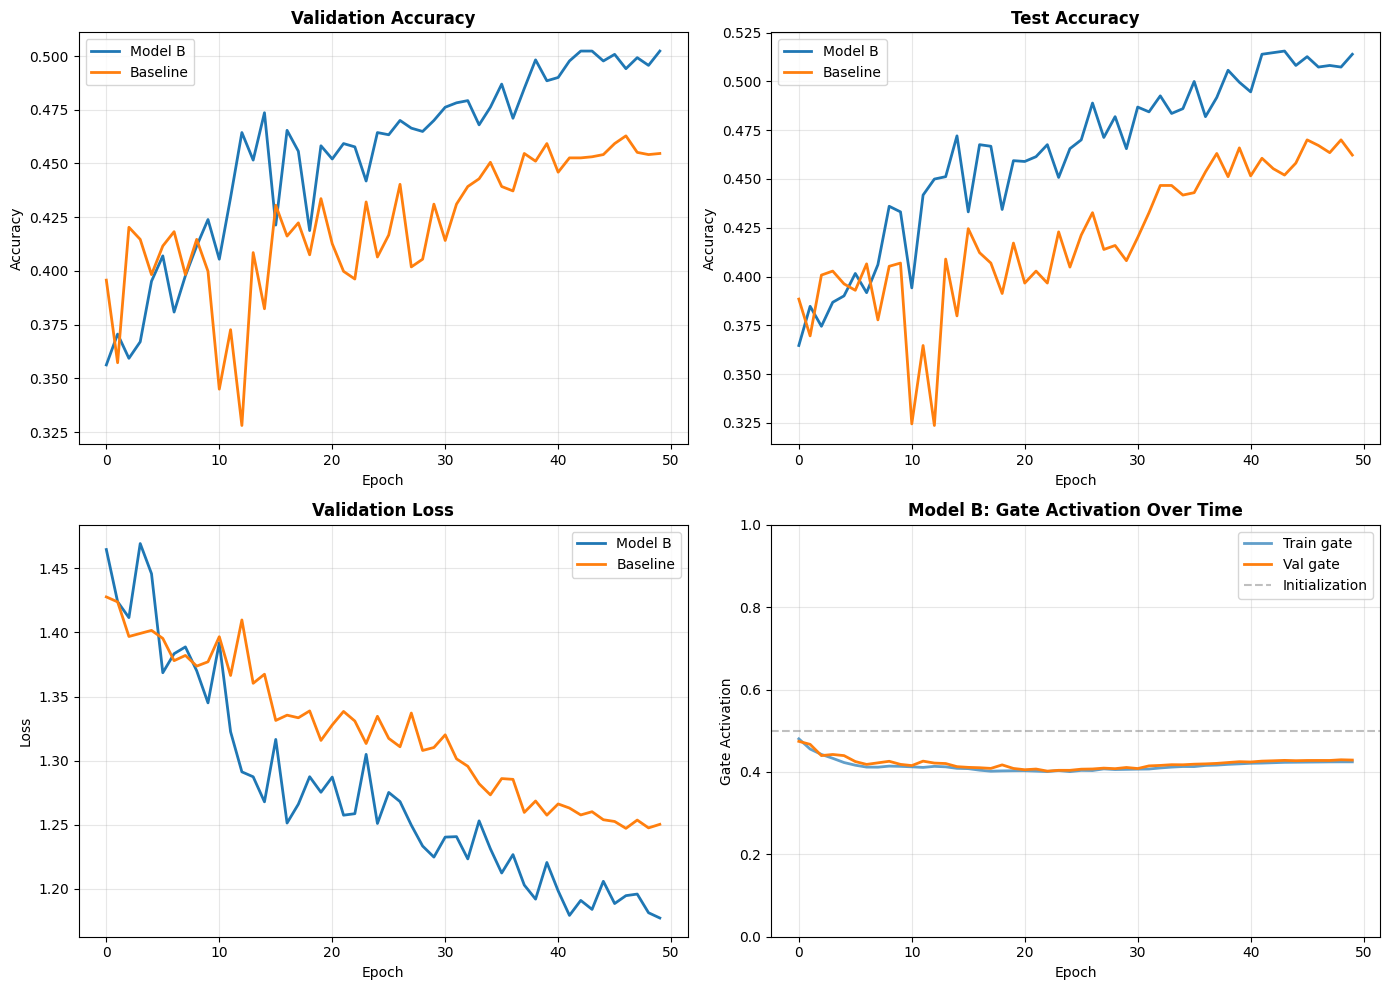

Comparison plot saved to ../models/model_b/comparison_curves.png


In [18]:
# Plot accuracy curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Val accuracy
axes[0, 0].plot(history_b['val_acc'], label='Model B', linewidth=2)
axes[0, 0].plot(history_baseline['val_acc'], label='Baseline', linewidth=2)
axes[0, 0].set_title('Validation Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Test accuracy
axes[0, 1].plot(history_b['test_acc'], label='Model B', linewidth=2)
axes[0, 1].plot(history_baseline['test_acc'], label='Baseline', linewidth=2)
axes[0, 1].set_title('Test Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Val loss
axes[1, 0].plot(history_b['val_loss'], label='Model B', linewidth=2)
axes[1, 0].plot(history_baseline['val_loss'], label='Baseline', linewidth=2)
axes[1, 0].set_title('Validation Loss', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Gate activation (Model B only)
axes[1, 1].plot(history_b['train_gate'], label='Train gate', linewidth=2, alpha=0.7)
axes[1, 1].plot(history_b['val_gate'], label='Val gate', linewidth=2)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Initialization')
axes[1, 1].set_title('Model B: Gate Activation Over Time', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Gate Activation')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Comparison plot saved to {OUTPUT_DIR}/comparison_curves.png")

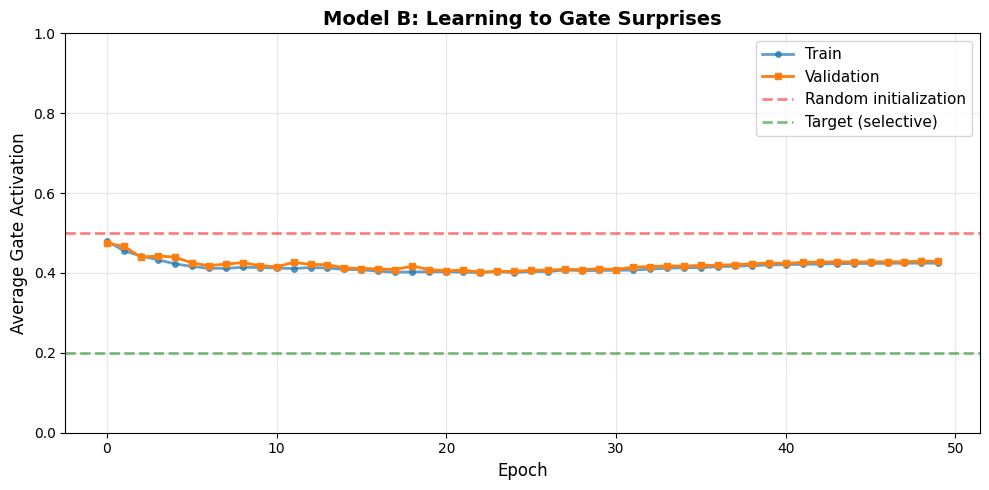

Gate learning plot saved to ../models/model_b/gate_learning.png


In [16]:
# Gate activation learning
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history_b['train_gate'], label='Train', linewidth=2, marker='o', markersize=4, alpha=0.7)
ax.plot(history_b['val_gate'], label='Validation', linewidth=2, marker='s', markersize=4)
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Random initialization')
ax.axhline(y=0.2, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target (selective)')

ax.set_title('Model B: Learning to Gate Surprises', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Average Gate Activation', fontsize=12)
ax.set_ylim([0, 1])
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gate_learning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Gate learning plot saved to {OUTPUT_DIR}/gate_learning.png")

## 9. Key Insights

**Did surprise propagation work?**

Look at the gate activation plot above:

- **✓ Success:** Gates dropped from ~0.5 to ~0.2-0.3, converged faster than Baseline
  - Interpretation: Surprise-only propagation is a real principle
  - Next: Test on NLP and larger scales

- **✗ Failure:** Gates stayed near 0.9-1.0, no speed advantage
  - Interpretation: Error signal too noisy, predictors can't learn
  - Next: Try Model A (full brain architecture with feedback)

- **? Mixed:** Same final accuracy, but unclear advantage
  - Interpretation: Principle works but not competitive yet
  - Next: Adjust loss weights, add skip connections, increase predictor capacity